Data Ingestion & Cleaning

--- Frequentist Summary ---
       Total Users (n)  Conversions (k)  Conversion Rate (p)
group                                                       
A                 1016              102             0.100394
B                  984              111             0.112805


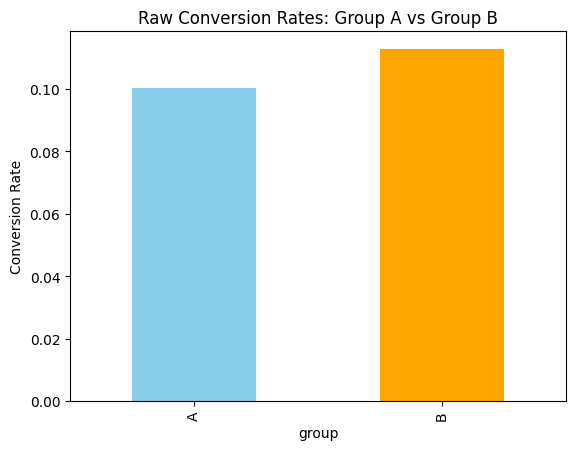

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data you generated
df = pd.read_csv('../data/experiment_results.csv')

# 2. Calculate raw metrics
summary = df.groupby('group')['converted'].agg(['count', 'sum', 'mean'])
summary.columns = ['Total Users (n)', 'Conversions (k)', 'Conversion Rate (p)']

print("--- Frequentist Summary ---")
print(summary)

# 3. Quick Visualization
summary['Conversion Rate (p)'].plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Raw Conversion Rates: Group A vs Group B')
plt.ylabel('Conversion Rate')
plt.show()

Inference (The Posterior)

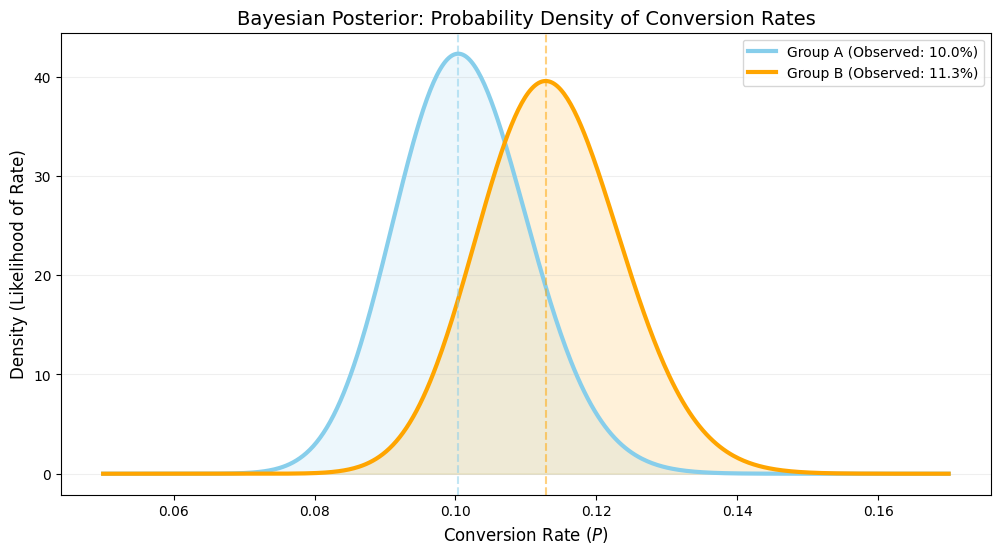

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# --- 1. DATA EXTRACTION ---
# Pulling n and k for each group from the summary table
n_a, k_a = summary.loc['A', ['Total Users (n)', 'Conversions (k)']]
n_b, k_b = summary.loc['B', ['Total Users (n)', 'Conversions (k)']]

# --- 2. PARAMETER SPACE (The x-axis) ---
# We define a range of possible conversion rates (theta) to evaluate.
x = np.linspace(0.05, 0.17, 500)

# --- 3. POSTERIOR CALCULATION ---
# WHY THE BETA DISTRIBUTION?
# 1. CONJUGATE PRIOR: The Beta distribution is the "conjugate prior" to the Binomial 
#    distribution. Because our data is Binomial (success/failure), the posterior 
#    is mathematically guaranteed to be a Beta distribution.
#
# 2. ANALYTIC SOLUTION: This allows us to calculate the 'Evidence' (normalization 
#    constant) automatically. scipy.stats.beta.pdf ensures the area under the curve is 1.0.
#
# UPDATING RULE: Posterior Alpha = Prior Alpha + Successes | Posterior Beta = Prior Beta + Failures
# We use +1 to represent a "Flat/Uniform Prior" (Laplace Smoothing).

pdf_a = beta.pdf(x, k_a + 1, (n_a - k_a) + 1)
pdf_b = beta.pdf(x, k_b + 1, (n_b - k_b) + 1)

# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 6))

# Plot the "Degree of Belief" for both versions
plt.plot(x, pdf_a, label=f'Group A (Observed: {k_a/n_a:.1%})', color='skyblue', lw=3)
plt.plot(x, pdf_b, label=f'Group B (Observed: {k_b/n_b:.1%})', color='orange', lw=3)

# Fill the area to visualize the overlap (uncertainty zone)
plt.fill_between(x, pdf_a, alpha=0.15, color='skyblue')
plt.fill_between(x, pdf_b, alpha=0.15, color='orange')

# Technical Formatting
plt.title('Bayesian Posterior: Probability Density of Conversion Rates', fontsize=14)
plt.xlabel('Conversion Rate ($P$)', fontsize=12)
plt.ylabel('Density (Likelihood of Rate)', fontsize=12)
plt.axvline(k_a/n_a, color='skyblue', linestyle='--', alpha=0.5)
plt.axvline(k_b/n_b, color='orange', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

Decision Metrics

In [3]:
# 1. Take 100,000 random "guesses" from each distribution
samples_a = beta.rvs(k_a + 1, (n_a - k_a) + 1, size=100000)
samples_b = beta.rvs(k_b + 1, (n_b - k_b) + 1, size=100000)

# 2. Count how many times the guess for B was higher than A
prob_b_better = (samples_b > samples_a).mean()

print(f"Probability that Group B is better than Group A: {prob_b_better:.2%}")

Probability that Group B is better than Group A: 81.69%


In [4]:
# 1. Calculate the magnitude of 'A being better than B' for every sample
# We use np.maximum to ignore cases where B is already winning (loss = 0)
loss_b = np.maximum(samples_a - samples_b, 0)

# 2. The Expected Loss is the mean of these potential losses
expected_loss_b = loss_b.mean()

print(f"Expected Loss if we switch to B: {expected_loss_b:.5f}")

# Threshold check (Industry standard is often 0.001 or 0.1% of the rate)
threshold = 0.0005 
if expected_loss_b < threshold:
    print("Risk is below threshold. Safe to stop and switch.")
else:
    print("Risk is still too high. Continue gathering data.")

Expected Loss if we switch to B: 0.00139
Risk is still too high. Continue gathering data.


In [5]:
# Calculate the 95% HDI (2.5th and 97.5th percentiles)
hdi_a = np.percentile(samples_a, [2.5, 97.5])
hdi_b = np.percentile(samples_b, [2.5, 97.5])

print(f"Group A 95% HDI: [{hdi_a[0]:.4f}, {hdi_a[1]:.4f}]")
print(f"Group B 95% HDI: [{hdi_b[0]:.4f}, {hdi_b[1]:.4f}]")

Group A 95% HDI: [0.0834, 0.1204]
Group B 95% HDI: [0.0946, 0.1340]


Now, call one function to perform the whole analysis.

In [6]:
import sys
import os

# Adds the 'src' directory to the path so you can import your engine
sys.path.append(os.path.abspath('../src'))

from bayesian_engine import compute_posterior_metrics

In [7]:
metrics = compute_posterior_metrics(n_a, k_a, n_b, k_b)

results_df = pd.DataFrame({
    "Metric": ["Probability B > A", "Expected Loss", "Group A 95% HDI", "Group B 95% HDI"],
    "Value": [
        f"{metrics['prob_b_better']:.2%}",
        f"{metrics['expected_loss']:.5f}",
        f"{metrics['hdi_a']}",
        f"{metrics['hdi_b']}"
    ]
})

display(results_df)

,Metric,Value
0,Probability B > A,81.45%
1,Expected Loss,0.00141
2,Group A 95% HDI,[0.08342366 0.12043798]
3,Group B 95% HDI,[0.09456303 0.13418798]


What about a better-informed prior?...

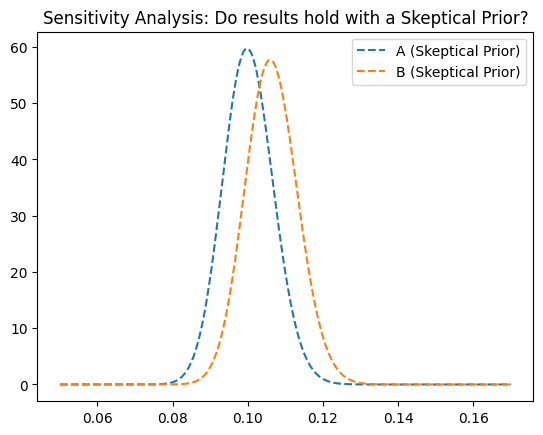

In [8]:
# Try a "Skeptical" Prior: Assume we strongly believe the rate is 10%
# Beta(100, 900) represents 100 successes and 900 failures observed previously.
prior_alpha, prior_beta = 100, 900

pdf_a_skeptical = beta.pdf(x, k_a + prior_alpha, (n_a - k_a) + prior_beta)
pdf_b_skeptical = beta.pdf(x, k_b + prior_alpha, (n_b - k_b) + prior_beta)

plt.plot(x, pdf_a_skeptical, label="A (Skeptical Prior)", linestyle='--')
plt.plot(x, pdf_b_skeptical, label="B (Skeptical Prior)", linestyle='--')
plt.legend()
plt.title("Sensitivity Analysis: Do results hold with a Skeptical Prior?")
plt.show()